# Newsroom: analysis notebook

Companion to the web app (`app/app.py`). Set `CORPUS` to any built corpus (`corpora/<id>.toml` with a
`data/<id>/index.db`); sections 1–8 read that index, section 9 reads the cross-collection index
(`data/global.db`) and every built corpus.

**Contents:** 0. what is built · 1. corpus overview · 2. full-text search · 3. entities · 4. network analysis
(centrality, bridges, communities) · 5. lead-finding queries · 6. direct relations (email / registry data) ·
7. timelines · 8. this corpus's entities elsewhere · 9. across all collections (shared entities, collection overlap,
cross-collection timelines) · 10. Gephi export.

> Entities marked `auto=1` were detected automatically (codenames, NER, patterns) and are noisier than the curated ones.
> Co-occurrence is not a relationship: always read the pages. Across collections, entities are matched by type and name,
> so different people with the same name are merged there.

In [1]:
CORPUS = 'snowden'          # any id from corpora/*.toml that has been built

import os, re, sys, json, sqlite3, math, collections
import pandas as pd, networkx as nx, matplotlib.pyplot as plt
PROJECT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebook' else os.getcwd()
sys.path.insert(0, PROJECT)
from lib.config import load_corpus, list_corpora
from lib import globalindex

C = load_corpus(CORPUS)
con = sqlite3.connect(f'file:{C.db_path}?mode=ro', uri=True)
sql = lambda q, *a: pd.read_sql_query(q, con, params=a)
has_table = lambda name, c=con: c.execute("SELECT 1 FROM sqlite_master WHERE type='table' AND name=?", (name,)).fetchone() is not None
pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 200)
palette = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']

def tidy(ax, ylabel=''):
    ax.set_xlabel(''); ax.set_ylabel(ylabel); ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()

print(C.title, '→', C.db_path)
sql("SELECT k, v FROM meta")

Snowden Archive → /Volumes/Expansion/Documents/notebooks/newsroom/data/snowden/index.db


,k,v
0,built,2026-10-08 20:13:57
1,documents,2996
2,pages,15080
3,archive,/Volumes/Expansion/Documents/futurist-society/journalism/hacks and leaks/snowden
4,corpus,snowden
5,title,Snowden Archive
6,packs,"core,markings,government,sigint"
7,ner,PERSON


## 0. What is built

Every configured corpus, with its index if it has one. The app's library page shows the same.

In [2]:
rows = []
for c in list_corpora():
    row = {'corpus': c.id, 'title': c.title, 'built': ''}
    if c.exists():
        x = sqlite3.connect(f'file:{c.db_path}?mode=ro', uri=True)
        meta = dict(x.execute('SELECT k, v FROM meta'))
        row.update(built=meta.get('built', '')[:10], documents=int(meta.get('documents', 0)), pages=int(meta.get('pages', 0)),
                   entities=x.execute('SELECT COUNT(*) FROM entities').fetchone()[0], ner=meta.get('ner', ''))
        x.close()
    rows.append(row)
status = pd.DataFrame(rows).set_index('corpus')
status.sort_values('documents', ascending=False, na_position='last')

,title,built,documents,pages,entities,ner
corpus,,,,,,
cablegate,Cablegate,2026-10-08,251287.0,284699.0,94857.0,PERSON
afghan-war-logs,Afghan War Diary,2026-10-05,76911.0,76915.0,576.0,off
conti-chats,Conti chats,2026-10-05,9614.0,9749.0,411.0,off
mlk-2025,MLK Assassination Records (2025),2026-10-09,6302.0,243494.0,8063.0,PERSON
jfk,JFK Assassination Records,2026-10-09,3791.0,21678.0,3543.0,PERSON
snowden,Snowden Archive,2026-10-08,2996.0,15080.0,1543.0,PERSON
jfk-2025,JFK Records (2025 release),2026-10-08,2674.0,86722.0,5262.0,PERSON
rfk,RFK Assassination Records,2026-10-09,1969.0,84528.0,8495.0,PERSON
declassified,Declassified government releases,2026-10-09,884.0,57158.0,13373.0,"ORG,PERSON"


## 1. Corpus overview

In [3]:
sql('''SELECT collection, COUNT(*) docs, SUM(pages) pages, SUM(ocr_pages) ocr_pages
          FROM documents GROUP BY collection ORDER BY docs DESC LIMIT 30''')

,collection,docs,pages,ocr_pages
0,sidtoday,2164,3401,7
1,(top level),514,8253,4249
2,germany,52,202,156
3,tao,49,49,48
4,dni-fisc-yahoo-14-0911,48,1240,1083
5,spiegel-122814,45,670,557
6,menwith-hill-station,27,99,99
7,USA v Lavabit LLC,26,509,15
8,spiegel-15-0117,15,207,200
9,supply-chain,9,75,5


In [4]:
display(sql("SELECT kind, COUNT(*) docs FROM documents GROUP BY kind ORDER BY docs DESC"))
display(sql("SELECT origin, COUNT(*) docs FROM documents GROUP BY origin ORDER BY docs DESC LIMIT 20"))
display(sql("SELECT classification, COUNT(*) docs FROM documents GROUP BY classification ORDER BY docs DESC"))

,kind,docs
0,pdf,2873
1,image,89
2,image-set,27
3,html,4
4,text,3


,origin,docs
0,NSA (U.S.),2464
1,Other / unknown,293
2,U.S. court filing,91
3,GCHQ (UK),89
4,CSEC (Canada),36
5,U.S. government (other),7
6,GCSB (New Zealand),6
7,Web page (press/Cryptome),4
8,FBI (U.S.),2
9,DHS (U.S.),2


,classification,docs
0,TOP SECRET,2632
1,,195
2,SECRET,111
3,UNCLASSIFIED,51
4,CONFIDENTIAL,7


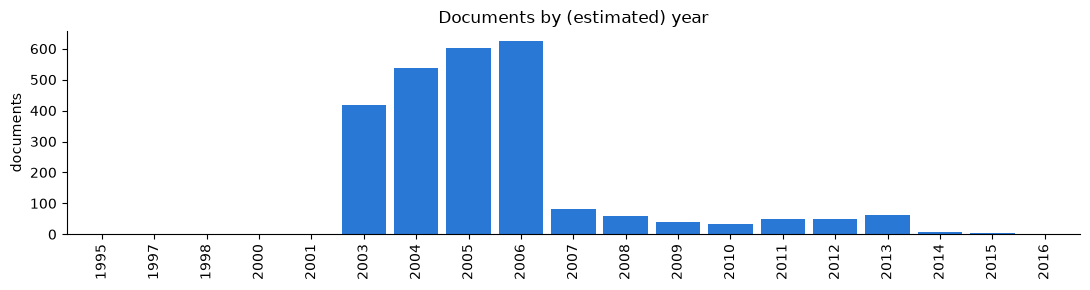

In [5]:
LO, HI = globalindex.year_range(C, con)       # the corpus's chart years, as in the app
yr = sql("SELECT year, COUNT(*) n FROM documents WHERE year BETWEEN ? AND ? GROUP BY year", LO, HI)
ax = yr.plot.bar(x='year', y='n', legend=False, figsize=(11, 3), color=palette[0], width=0.85)
ax.set_title('Documents by (estimated) year')
step = max(1, len(yr) // 25)
ax.set_xticks(range(0, len(yr), step)); ax.set_xticklabels(yr.year[::step])
tidy(ax, 'documents')

## 2. Full-text search

`search()` uses SQLite FTS5 syntax: `"exact phrase"`, `prefix*`, `A OR B`, `A NOT B`, `NEAR(a b, 10)`.

In [6]:
def search(q, limit=20):
    return sql('''SELECT d.title, d.doc_date, d.collection, p.page_no,
                         snippet(pages_fts, 0, '«', '»', ' … ', 24) AS snippet, d.id
                  FROM pages_fts JOIN pages p ON p.rowid = pages_fts.rowid JOIN documents d ON d.id = p.doc_id
                  WHERE pages_fts MATCH ? ORDER BY bm25(pages_fts) LIMIT ?''', q, limit)

def page(doc_id, page_no):
    r = con.execute('SELECT text FROM pages WHERE doc_id=? AND page_no=?', (doc_id, page_no)).fetchone()
    print(r[0] if r else '(not found)')

example = (C.ui.get('search_examples') or ['"human rights"'])[0]
print('query:', example)
search(example, 8)

query: "cable landing"


,title,doc_date,collection,page_no,snippet,id
0,pacnet1,,(top level),1,… Network POP\n> e Service POP\n«Cable landing»\n\nSMP,3a906f8604d6
1,GCHQ/NSA Bude Tempora Global Spying Station Donate for DVDs of the Cryptome archive of 70.000 files from 1996 to the...,2013-06-22,GCHQ_NSA Bude Tempora Global Spying Station_files,1,"… 2013-00405 Submarine «Cable Landing» Worldwide Map June 22, 2013 \n 2013-00404 Submarine Cable Worldwide Map June...",6f6df20a79d7


## 3. Entities

In [7]:
sql("SELECT type, COUNT(*) entities, SUM(auto) auto_detected FROM entities GROUP BY type ORDER BY entities DESC")

,type,entities,auto_detected
0,person,451,323
1,program,409,343
2,place,375,0
3,company,81,0
4,agency,77,0
5,organization,67,0
6,idea,47,0
7,technology,36,0


In [8]:
for t in [r[0] for r in con.execute("SELECT DISTINCT type FROM entities")]:
    print(f'--- {t}')
    display(sql("SELECT name, doc_count, mention_count, first_year, last_year, auto FROM entities WHERE type=? ORDER BY doc_count DESC LIMIT 12", t))

--- agency


,name,doc_count,mention_count,first_year,last_year,auto
0,NSA,1742,11350,1981,2015,0
1,SIGINT Directorate (SID),1224,4192,1998,2014,0
2,ODNI,319,3606,1995,2014,0
3,CIA,276,835,1981,2014,0
4,Five Eyes,270,758,1998,2015,0
5,GCHQ,258,1154,1998,2015,0
6,FBI,193,1893,1981,2014,0
7,Department of Defense,192,574,1981,2014,0
8,DIA,132,316,1981,2014,0
9,TAO,122,549,2003,2015,0


--- place


,name,doc_count,mention_count,first_year,last_year,auto
0,United States,915,9175,1981,2016,0
1,Iraq,385,1085,1998,2015,0
2,United Kingdom,258,1308,1998,2015,0
3,Afghanistan,210,472,2003,2015,0
4,Europe,161,282,2003,2015,0
5,China,157,668,1998,2015,0
6,Middle East,147,238,2003,2015,0
7,Russia,145,283,1998,2015,0
8,Baghdad,135,406,2003,2009,0
9,Pakistan,132,297,1998,2015,0


--- technology


...

,name,doc_count,mention_count,first_year,last_year,auto
0,al-Qaida,119,286,2001,2013,0
1,United Nations,84,286,2003,2015,0
2,Reuters,68,120,1981,2014,0
3,NATO,53,195,1998,2013,0
4,European Union,41,78,2003,2015,0
5,Anonymous / hacktivists,35,74,2003,2015,0
6,Taliban,34,69,2003,2011,0
7,The Washington Post,31,69,2004,2014,0
8,The Intercept,24,64,1998,2014,0
9,Hezbollah,22,88,2004,2012,0


--- company


,name,doc_count,mention_count,first_year,last_year,auto
0,Google,99,621,2004,2015,0
1,Yahoo,97,1265,1981,2014,0
2,Microsoft,79,206,2004,2015,0
3,Facebook,51,164,2005,2015,0
4,Thuraya / Inmarsat / Iridium,42,96,2003,2013,0
5,Mozilla / Firefox,37,230,2004,2015,0
6,Apple,36,75,2004,2015,0
7,Lavabit,26,1033,2013,2016,0
8,Skype,26,199,2005,2014,0
9,Twitter,26,117,2007,2015,0


--- person


,name,doc_count,mention_count,first_year,last_year,auto
0,Richard Quirk,88,95,2003,2006,1
1,Michael Hayden,50,269,2001,2014,0
2,Marilyn Maines,46,88,2004,2006,1
3,Osama bin Laden,46,200,2003,2012,0
4,Charlie Meals,41,49,2003,2006,1
5,Keith Alexander,38,75,2004,2014,0
6,Charles Berlin,37,41,2003,2006,1
7,Saddam Hussein,37,57,2003,2009,0
8,Roland Recker,36,41,2004,2006,1
9,Edward Snowden,34,1433,2012,2015,0


## 4. Network analysis

A weighted graph from the co-occurrence table. Hubs connect to almost everything, so entities in more than `MAX_DF`
documents (the corpus's "hide hubs" setting) are left out, edges need at least `MIN_DOCS` shared documents, and only the
`NODE_CAP` most documented entities are kept so centrality stays quick on big corpora (cablegate has 95,000 entities).

In [9]:
MIN_DOCS, MAX_DF, NODE_CAP = 3, C.ui.get('hide_hubs', 800), 3000
ents = sql("SELECT id, name, type, doc_count, auto FROM entities WHERE doc_count <= ? ORDER BY doc_count DESC LIMIT ?",
           MAX_DF, NODE_CAP).set_index('id')
ids = ','.join(map(str, ents.index))
edges = sql(f"SELECT src, dst, docs, npmi FROM edges WHERE docs >= ? AND src IN ({ids}) AND dst IN ({ids})", MIN_DOCS)
G = nx.Graph()
for i, r in ents.iterrows():
    G.add_node(i, name=r['name'], type=r['type'], docs=int(r['doc_count']), auto=int(r['auto']))
G.add_weighted_edges_from(edges[['src', 'dst', 'docs']].itertuples(index=False), weight='docs')
for s, d, n in edges[['src', 'dst', 'npmi']].itertuples(index=False):
    G[s][d]['npmi'] = n
G.remove_nodes_from([n for n in list(G) if G.degree(n) == 0])
print(G)

Graph with 809 nodes and 15507 edges


In [10]:
# Betweenness (sampled for speed): entities that bridge otherwise separate parts of the corpus
bc = nx.betweenness_centrality(G, k=min(400, len(G)), weight=None, seed=1)
df = pd.DataFrame({'name': nx.get_node_attributes(G, 'name'), 'type': nx.get_node_attributes(G, 'type'),
                   'docs': nx.get_node_attributes(G, 'docs'), 'degree': dict(G.degree()), 'betweenness': bc})
# "bridge score": betweenness relative to how common the entity is
df['bridge_score'] = df.betweenness / df.docs.pow(0.5)
df.sort_values('betweenness', ascending=False).head(25)

,name,type,docs,degree,betweenness,bridge_score
4,Email,technology,547,357,0.088880,0.003800
5,Iraq,place,385,312,0.049066,0.002501
19,Offensive hacking (CNE/CNA),idea,198,292,0.044747,0.003180
6,ODNI,agency,319,322,0.044432,0.002488
15,Counterterrorism,idea,242,343,0.042752,0.002748
11,United Kingdom,place,258,288,0.040531,0.002523
9,Terrorism,idea,265,347,0.039611,0.002433
18,Satellite (VSAT / FORNSAT),technology,202,195,0.033180,0.002335
41,Legal authorities (FISA/702/12333),idea,120,273,0.030224,0.002759
17,Afghanistan,place,210,256,0.027957,0.001929


In [11]:
df[df.docs >= 5].sort_values('bridge_score', ascending=False).head(25)

,name,type,docs,degree,betweenness,bridge_score
4,Email,technology,547,357,0.088880,0.003800
19,Offensive hacking (CNE/CNA),idea,198,292,0.044747,0.003180
41,Legal authorities (FISA/702/12333),idea,120,273,0.030224,0.002759
15,Counterterrorism,idea,242,343,0.042752,0.002748
11,United Kingdom,place,258,288,0.040531,0.002523
5,Iraq,place,385,312,0.049066,0.002501
6,ODNI,agency,319,322,0.044432,0.002488
9,Terrorism,idea,265,347,0.039611,0.002433
18,Satellite (VSAT / FORNSAT),technology,202,195,0.033180,0.002335
37,Germany,place,125,234,0.025766,0.002305


In [12]:
# Communities (Louvain on shared-document weights)
comms = nx.community.louvain_communities(G, weight='docs', seed=7, resolution=1.2)
rows = []
for i, c in enumerate(sorted(comms, key=len, reverse=True)[:20]):
    top = sorted(c, key=lambda n: -G.nodes[n]['docs'])[:14]
    rows.append({'community': i, 'size': len(c), 'top members': ', '.join(G.nodes[n]['name'] for n in top)})
pd.DataFrame(rows)

,community,size,top members
0,0,189,"Email, Exploits / zero-days, Encryption, Offensive hacking (CNE/CNA), Automation, analytics & ML, GSM / mobile netwo..."
1,1,174,"Iraq, CIA, Terrorism, Workforce & culture, Counterterrorism, Afghanistan, Baghdad, DIA, al-Qaida, Fort Meade, Langua..."
2,2,174,"ODNI, FBI, Department of Defense, U.S. Congress, Legal authorities (FISA/702/12333), Maryland, Washington, D.C., Und..."
3,3,173,"Europe, China, Middle East, Russia, Pakistan, Africa, Iran, Germany, United Nations, Japan, India, Israel, France, N..."
4,4,82,"Five Eyes, GCHQ, United Kingdom, Partner sharing & liaison, Satellite (VSAT / FORNSAT), Radar / radio, Menwith Hill,..."
5,5,13,"Economic & financial intelligence, Marilyn Maines, Diplomatic targeting, Roland Recker, Oil, gas & energy, Richard N..."
6,6,2,"Charlie Speight, OUTPARKS"
7,7,2,"PIEDMONT, PITCHFORD"


## 5. Lead-finding queries

Pairs that co-occur far more than chance predicts (high NPMI), restricted to interesting type combinations. These are
leads, not facts: open the documents.

In [13]:
def distinctive_pairs(type_a, type_b, min_docs=3, limit=30):
    return sql('''SELECT a.name AS a, b.name AS b, e.docs, ROUND(e.npmi, 3) npmi, a.doc_count a_docs, b.doc_count b_docs
                  FROM edges e JOIN entities a ON a.id=e.src JOIN entities b ON b.id=e.dst
                  WHERE ((a.type=? AND b.type=?) OR (a.type=? AND b.type=?)) AND e.docs >= ?
                  ORDER BY e.npmi DESC LIMIT ?''', type_a, type_b, type_b, type_a, min_docs, limit)

distinctive_pairs('person', 'organization')

,a,b,docs,npmi,a_docs,b_docs
0,Fox News,James Risen,3,0.958,4,3
1,WikiLeaks,Chelsea Manning,8,0.932,12,8
2,PKK,Recep Tayyip Erdoğan,3,0.841,9,3
3,WikiLeaks,Julian Assange,4,0.834,12,4
4,PKK,Stephen Hadley,3,0.799,9,4
5,The Guardian,Daniel Ellsberg,3,0.799,12,3
6,The Guardian,James Risen,3,0.799,12,3
7,WikiLeaks,Daniel Ellsberg,3,0.799,12,3
8,The Wall Street Journal,Recep Tayyip Erdoğan,3,0.788,13,3
9,Maureen Baginski,Warsaw Pact,3,0.784,10,4


In [14]:
distinctive_pairs('company', 'place')

,a,b,docs,npmi,a_docs,b_docs
0,Lavabit,Dallas,10,0.761,26,15
1,Virginia,Lavabit,20,0.678,77,26
2,Los Angeles,SAIC / Lockheed / defense contractors,3,0.644,15,7
3,Moscow,Kaspersky,3,0.599,24,6
4,Lavabit,Nebraska,4,0.579,26,10
5,France,Gemalto,3,0.569,59,3
6,Lavabit,Seattle,4,0.539,26,13
7,Hong Kong,Verizon,3,0.532,19,12
8,Lavabit,San Francisco,4,0.528,26,14
9,"Washington, D.C.",Yahoo,35,0.524,105,97


In [15]:
distinctive_pairs('person', 'program', min_docs=2)

,a,b,docs,npmi,a_docs,b_docs
0,Ronald Pofalla,PFISTER,2,1.000,2,2
1,Goddard Greenbelt,DISTANTFOCUS,2,1.000,2,2
2,Ingvar Åkesson,WINTERLIGHT,4,1.000,4,4
3,Billy Mitchell,NCPRA,2,1.000,2,2
4,Ted Stevens,NCPRA,2,1.000,2,2
5,Benjamin Stove,MMORPG,2,1.000,2,2
6,Nick Yee,DARWARS,2,1.000,2,2
7,Benjamin Stove,CIRAS,2,1.000,2,2
8,Benjamin Stove,RMMOG,2,1.000,2,2
9,Nick Yee,MMORPG,2,1.000,2,2


In [16]:
def entity_id(name):
    r = con.execute('SELECT id FROM entities WHERE name=? ORDER BY doc_count DESC LIMIT 1', (name,)).fetchone()
    return r[0] if r else None

def docs_with_both(a, b, limit=25):
    return sql('''SELECT d.id, d.title, d.doc_date, d.collection FROM documents d
                  WHERE d.id IN (SELECT doc_id FROM mentions WHERE entity_id=?)
                    AND d.id IN (SELECT doc_id FROM mentions WHERE entity_id=?)
                  ORDER BY d.doc_date LIMIT ?''', entity_id(a), entity_id(b), limit)

top_people = [r[0] for r in con.execute("SELECT name FROM entities WHERE type='person' AND auto=0 ORDER BY doc_count DESC LIMIT 2")]
print(top_people)
docs_with_both(*top_people) if len(top_people) == 2 else None

['Michael Hayden', 'Osama bin Laden']


,id,title,doc_date,collection
0,dc92a5af1301,npth 05,,greenwald
1,fa4957d2b613,nsa nyt warrantless wiretap,2004,(top level)


## 6. Direct relations

Typed links from structured data: email sender → recipient, ICIJ officer → company, registered addresses. Empty for
corpora without structured sources.

In [17]:
rel = sql('''SELECT a.name AS source, r.type, b.name AS target, r.docs, r.first_date, r.last_date
               FROM relations r JOIN entities a ON a.id=r.src JOIN entities b ON b.id=r.dst
               ORDER BY r.docs DESC LIMIT 40''') if has_table('relations') else pd.DataFrame()
rel

,source,type,target,docs,first_date,last_date


In [18]:
# Who talks to whom: directed email graph, ranked by PageRank
if len(rel):
    R = nx.DiGraph()
    for s, t, d in con.execute('''SELECT a.name, b.name, r.docs FROM relations r JOIN entities a ON a.id=r.src
                                   JOIN entities b ON b.id=r.dst WHERE r.type IN ('emailed', 'messaged')'''):
        R.add_edge(s, t, weight=d)
    if len(R):
        pr = nx.pagerank(R, weight='weight')
        display(pd.Series(pr).sort_values(ascending=False).head(20).rename('pagerank').to_frame())

## 7. Timelines

Share of each year's dated documents that mention an entity, which corrects for uneven coverage. Years with fewer than
`min_year_docs` dated documents are left out, as in the app: one document makes a 100% spike. (The query starts from the
entity so SQLite can use the mentions index; filtering on year first makes it scan the whole table.)

,Iraq,United Kingdom,Afghanistan,Europe,China
year,,,,,
2003,17.2,2.6,6.7,3.1,4.5
2004,14.1,4.3,4.3,3.5,5.2
2005,17.9,6.5,8.0,6.1,3.6
2006,11.7,8.3,6.2,6.6,4.5
2007,14.6,12.2,6.1,9.8,6.1
2008,11.7,6.7,11.7,1.7,3.3
2009,22.0,17.1,19.5,4.9,17.1
2010,9.4,18.8,15.6,6.2,3.1
2011,0.0,27.1,27.1,8.3,10.4


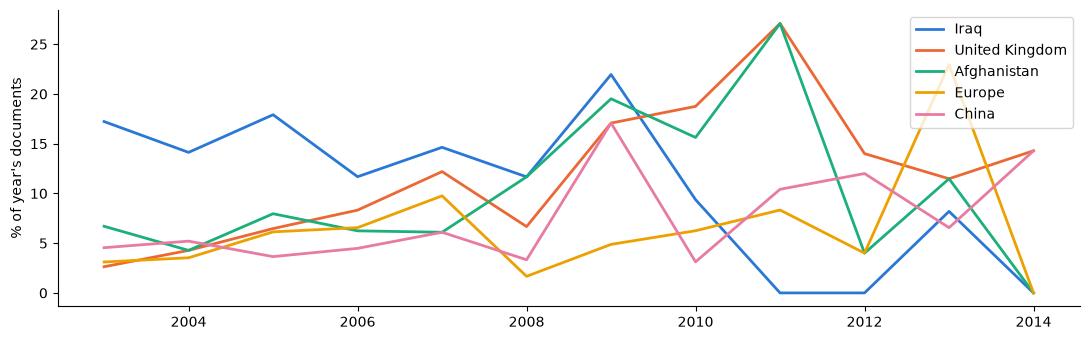

In [19]:
def year_counts(c, entity_ids, lo, hi):
    if not entity_ids:
        return pd.Series(dtype=int)
    q = f'''SELECT d.year, COUNT(DISTINCT d.id) n FROM mentions m JOIN documents d ON d.id = m.doc_id
            WHERE m.entity_id IN ({','.join('?' * len(entity_ids))}) AND d.year BETWEEN ? AND ? GROUP BY d.year'''
    return pd.read_sql_query(q, c, params=[*entity_ids, lo, hi]).set_index('year').n

def timeline(names, start=None, end=None, min_year_docs=5):
    start, end = start or LO, end or HI
    tot = sql("SELECT year, COUNT(*) n FROM documents WHERE year BETWEEN ? AND ? GROUP BY year", start, end).set_index('year').n
    tot = tot[tot >= min_year_docs]
    return pd.DataFrame({n: (100 * year_counts(con, [entity_id(n)] if entity_id(n) else [], start, end) / tot)
                             .reindex(tot.index).fillna(0) for n in names})

places = [r[0] for r in con.execute("SELECT name FROM entities WHERE type='place' ORDER BY doc_count DESC LIMIT 6")][1:6]
t = timeline(places)
ax = t.plot(figsize=(11, 3.5), color=palette[:len(t.columns)], linewidth=2)
tidy(ax, "% of year's documents")
t.round(1).tail(15)

## 8. This corpus's entities elsewhere

The cross-collection index (`data/global.db`, the one behind the app's `/all/` pages) merges entities from every built
corpus by type and folded name. Opening it here rebuilds it first if a corpus index changed since it was made.

In [20]:
built = [c for c in list_corpora() if c.exists()]
gcon, updating = globalindex.open_current(built)
gsql = lambda q, *a: pd.read_sql_query(q, gcon, params=a)
gsql("SELECT cid AS corpus, title, docs, lo AS first_year, hi AS last_year FROM corpora ORDER BY docs DESC")

,corpus,title,docs,first_year,last_year
0,cablegate,Cablegate,251287,1966,2010
1,afghan-war-logs,Afghan War Diary,76911,2004,2009
2,conti-chats,Conti chats,9614,2021,2022
3,mlk-2025,MLK Assassination Records (2025),6302,1950,1999
4,jfk,JFK Assassination Records,3791,1941,1999
5,snowden,Snowden Archive,2996,1990,2016
6,jfk-2025,JFK Records (2025 release),2674,1940,1998
7,rfk,RFK Assassination Records,1969,1943,1989
8,declassified,Declassified government releases,884,1940,2026
9,panama-papers,Panama Papers,154,1982,2016


In [21]:
# named entities of this corpus (not places or themes) that also appear in other collections
gsql('''SELECT e.name, e.type, SUM(l.doc_count) AS docs_here, e.doc_count AS docs_everywhere, e.n_corpora AS collections
        FROM local l JOIN entities e ON e.gkey = l.gkey
        WHERE l.cid = ? AND e.n_corpora > 1 AND e.auto = 0 AND e.type NOT IN ('place', 'idea')
        GROUP BY e.gkey ORDER BY e.n_corpora DESC, docs_here DESC LIMIT 25''', CORPUS)

,name,type,docs_here,docs_everywhere,collections
0,European Union,organization,41,39842,10
1,FBI,agency,193,11967,9
2,DIA,agency,132,1642,9
3,United Nations,organization,84,60109,9
4,CNN,organization,15,1388,9
5,IRS,agency,8,909,9
6,Red Cross,organization,3,4595,9
7,FSB,agency,1,543,9
8,NSA,agency,1742,3749,8
9,CIA,agency,276,6527,8


In [22]:
def across(name, etype=None):
    """Where an entity appears, collection by collection (matched like the app: type and folded name)."""
    keys = [globalindex.gkey(etype, name)] if etype else \
           [r[0] for r in gcon.execute("SELECT gkey FROM entities WHERE gkey IN (" + ','.join('?' * 9) + ")",
                                       [globalindex.gkey(t, name) for t in ('person', 'agency', 'company', 'program', 'technology',
                                                                            'place', 'organization', 'idea', 'identifier')])]
    if not keys:
        return pd.DataFrame()
    return gsql(f'''SELECT e.type, l.cid AS corpus, l.name AS name_there, l.doc_count AS docs, l.mention_count AS mentions
                    FROM local l JOIN entities e ON e.gkey = l.gkey WHERE l.gkey IN ({','.join('?' * len(keys))})
                    ORDER BY l.doc_count DESC''', *keys)

across(top_people[0] if top_people else 'United States')

,type,corpus,name_there,docs,mentions
0,person,snowden,Michael Hayden,50,269
1,person,declassified,Michael Hayden,19,136
2,person,cablegate,Michael Hayden,17,21


## 9. Across all collections

Entities found in the most collections, how much the collections overlap, and an entity's documents per year in every
collection that mentions it.

In [23]:
gsql('''SELECT name, type, n_corpora AS collections, doc_count AS documents, first_year, last_year
        FROM entities WHERE auto = 0 AND type NOT IN ('place', 'idea')
        ORDER BY n_corpora DESC, doc_count DESC LIMIT 30''')

,name,type,collections,documents,first_year,last_year
0,European Union,organization,10,39842,1952,2021
1,United Nations,organization,9,60109,1942,2026
2,FBI,agency,9,11967,1940,2026
3,Red Cross,organization,9,4595,1947,2010
4,DIA,agency,9,1642,1942,2021
5,CNN,organization,9,1388,1947,2018
6,IRS,agency,9,909,1943,2016
7,FSB,agency,9,543,1952,2021
8,National Security Council,agency,8,33589,1943,2014
9,State Department,agency,8,33516,1942,2017


,a,b,shared
10,cablegate,declassified,669
16,cablegate,snowden,665
35,jfk-2025,mlk-2025,612
37,jfk-2025,rfk,607
25,declassified,jfk-2025,606
12,cablegate,jfk-2025,600
29,declassified,snowden,594
30,jfk,jfk-2025,586
40,mlk-2025,rfk,580
26,declassified,mlk-2025,563


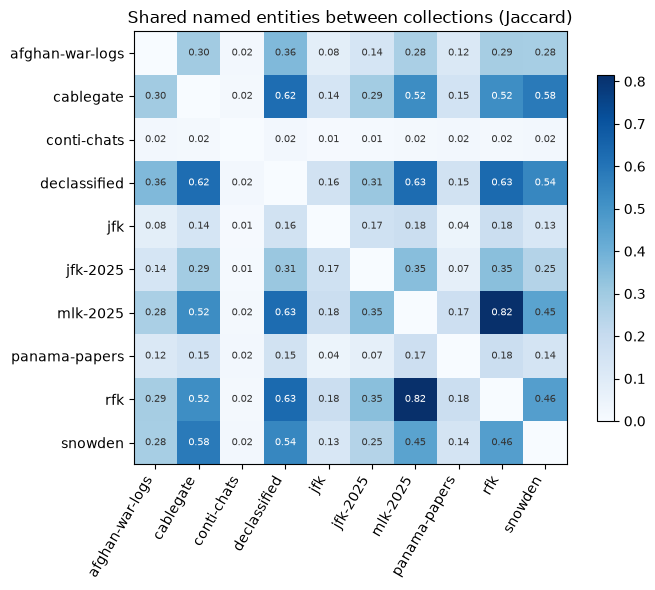

In [24]:
# collection overlap: share of named (non-auto) entities two collections have in common (Jaccard)
pairs = gsql('''SELECT a.cid AS a, b.cid AS b, COUNT(DISTINCT a.gkey) shared FROM local a JOIN local b ON a.gkey = b.gkey
                JOIN entities e ON e.gkey = a.gkey WHERE e.auto = 0 AND a.cid < b.cid GROUP BY a.cid, b.cid''')
sizes = gsql('''SELECT l.cid, COUNT(DISTINCT l.gkey) n FROM local l JOIN entities e ON e.gkey = l.gkey
                WHERE e.auto = 0 GROUP BY l.cid''').set_index('cid').n
names = list(sizes.index)
jac = pd.DataFrame(0.0, index=names, columns=names)
for a, b, s in pairs.itertuples(index=False):
    jac.loc[a, b] = jac.loc[b, a] = s / (sizes[a] + sizes[b] - s)
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(jac.values, cmap='Blues', vmin=0)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=60, ha='right')
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        if i != j and jac.iat[i, j] >= 0.005:
            ax.text(j, i, f'{jac.iat[i, j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if jac.iat[i, j] > jac.values.max() * 0.6 else '#333')
ax.set_title('Shared named entities between collections (Jaccard)')
fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout()
pairs.sort_values('shared', ascending=False).head(15)

the named person found in the most collections: George W. Bush (pass any name to across_years)


,afghan-war-logs,cablegate,declassified,jfk-2025,jfk,mlk-2025,rfk,snowden
documents,4,11786,14,5,4,7,1,29


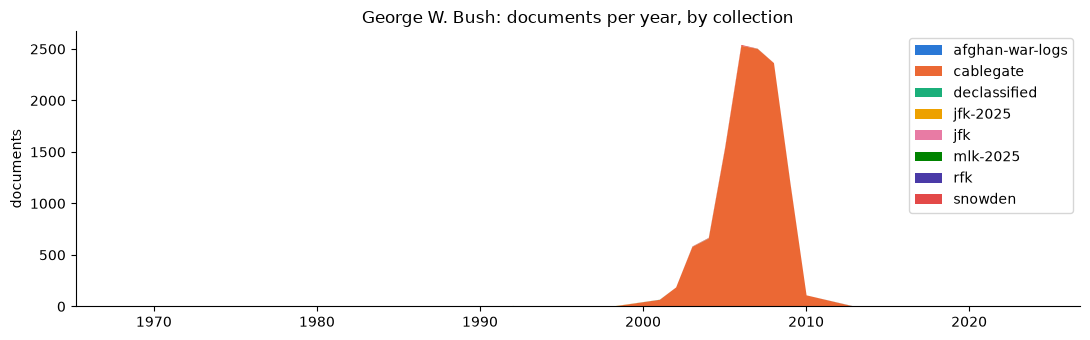

In [25]:
def across_years(name, etype='person'):
    """Documents per year mentioning an entity, by collection (each document once per collection)."""
    gk = globalindex.gkey(etype, name)
    bounds = {r[0]: (r[1], r[2]) for r in gcon.execute('SELECT cid, lo, hi FROM corpora')}
    keys = collections.defaultdict(list)
    for cid, key in gcon.execute('SELECT cid, key FROM local WHERE gkey = ?', (gk,)):
        keys[cid].append(key)
    out = {}
    for cid, ks in keys.items():
        c = load_corpus(cid)
        x = sqlite3.connect(f'file:{c.db_path}?mode=ro', uri=True)
        ids = [r[0] for r in x.execute(f"SELECT id FROM entities WHERE key IN ({','.join('?' * len(ks))})", ks)]
        out[cid] = year_counts(x, ids, *bounds[cid])
        x.close()
    return pd.DataFrame(out).fillna(0).astype(int).sort_index()

who = gsql('''SELECT name FROM entities WHERE type = 'person' AND auto = 0 ORDER BY n_corpora DESC, doc_count DESC LIMIT 1''').name[0]
print('the named person found in the most collections:', who, '(pass any name to across_years)')
by_year = across_years(who)
ax = by_year.plot.area(figsize=(11, 3.5), color=palette[:len(by_year.columns)], linewidth=0)
ax.set_title(f'{who}: documents per year, by collection')
tidy(ax, 'documents')
by_year.sum().rename('documents').to_frame().T

## 10. Export for Gephi / other tools

In [26]:
out = os.path.join(C.data_dir, 'graph.gexf')
H = G.copy()
for n in H:
    H.nodes[n]['label'] = H.nodes[n].pop('name')
nx.write_gexf(H, out)
print('wrote', out, H)

wrote /Volumes/Expansion/Documents/notebooks/newsroom/data/snowden/graph.gexf Graph with 809 nodes and 15507 edges
